In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Cookbook_Simulation_Workflow)=
# Working with OpenMM

*Setting up, parametrizing, simulating, and streaming molecular dynamics trajectories from MolSysMT to OpenMM.*

MolSysMT seamlessly integrates with OpenMM, allowing computational biophysicists to move effortlessly from raw experimental coordinates to energy minimization, equilibration, and production MD simulations.

In this recipe, we prepare the Villin Headpiece miniprotein, add missing caps and hydrogens, solvate it, construct an OpenMM Simulation context using direct MolSysMT conversion gateways, attach native reporters, execute a simulation run, and analyze the trajectory.

:::{versionadded} 1.0.0
:::


## System Preparation

We start by loading the Villin Headpiece structure, capping terminals, adding hydrogens, and solvating in a cubic box with 0.10 M NaCl:

In [2]:
import molsysmt as msm

# Load Villin Headpiece from bundled systems
molsys = msm.convert(msm.systems['chicken villin HP35']['chicken_villin_HP35.h5msm'], to_form='molsysmt.MolSys')
molsys = msm.build.add_missing_terminal_cappings(molsys)
molsys = msm.build.add_missing_hydrogens(molsys)

# Solvate with AMBER14 and TIP3P in a cubic box with 1.0 nm clearance
solvated_molsys = msm.build.solvate(
    [molsys, {'forcefield': 'AMBER14', 'water_model': 'TIP3P'}],
    box_shape='cubic',
    clearance='10.0 angstroms',
    to_form='molsysmt.MolSys',
    engine='OpenMM'
)

msm.info(solvated_molsys)

form,n_atoms,n_groups,n_components,n_chains,n_molecules,n_entities,n_waters,n_ions,n_peptides,n_structures
molsysmt.MolSys,7231,2248,2211,2,2211,3,2208,2,1,1


## Viewing Solvated System

We visualize the solvated protein before starting the simulation:

In [3]:
molsysviewer_htmlfile = '_static/views/cookbook_simulation_solvated.html'


In [4]:
msm.view(solvated_molsys)

'<iframe src="../../../_static/views/cookbook_simulation_solvated.html" width="100%" height="480px"\n        style="border:none;"></iframe>'

## Creating OpenMM Objects

We convert our prepared system directly into OpenMM native objects (`openmm.Topology` and `openmm.System`) via MolSysMT converters:

In [5]:
from openmm import app, unit, LangevinIntegrator, Platform
from molsysmt import pyunitwizard as puw

# Direct conversion to openmm.Topology and openmm.System
openmm_topology = msm.convert(solvated_molsys, to_form='openmm.Topology')
system = msm.convert(
    solvated_molsys,
    to_form='openmm.System',
    forcefield='AMBER14',
    water_model='TIP3P',
    non_bonded_method='PME',
    constraints='hbonds'
)

# Extract and convert coordinate units
coordinates = msm.get(solvated_molsys, coordinates=True)
positions = puw.convert(coordinates[0], to_form='openmm.unit')

print(f"OpenMM System created with {system.getNumParticles()} particles.")

OpenMM System created with 7231 particles.


## Configuring Simulation

We configure Langevin dynamics at 300 K, attach native MolSysMT reporters, and minimize potential energy:

In [6]:
# Integrator: Langevin dynamics at 300 K
integrator = LangevinIntegrator(300*unit.kelvin, 1.0/unit.picosecond, 2.0*unit.femtoseconds)
platform = Platform.getPlatformByName('CPU')
simulation = app.Simulation(openmm_topology, system, integrator, platform)
simulation.context.setPositions(positions)

# Energy minimization
simulation.minimizeEnergy(maxIterations=20)

# Attach MolSysMT StructuresDict reporter with periodic box tracking
from molsysmt.third_party.openmm.reporters import StructuresDictReporter

structures_reporter = StructuresDictReporter(10, box=True)
simulation.reporters.append(structures_reporter)

## Running Simulation

We execute the simulation steps and extract the collected frames into memory:

In [7]:
# Execute MD steps
simulation.step(50)

# Finalize reporter and construct MolSys trajectory
traj_dict = structures_reporter.finalize()
traj_molsys = msm.convert([solvated_molsys.topology, traj_dict], to_form='molsysmt.MolSys')

print(f"Captured {msm.get(traj_molsys, n_structures=True)} frames in memory.")

Captured 6 frames in memory.


## Trajectory Analysis

We calculate the C-alpha backbone RMSD progression across the simulation frames:

In [8]:
# Compute RMSD over the generated trajectory
rmsd_values = msm.structure.get_rmsd(
    traj_molsys,
    selection='atom_name=="CA"',
    reference_structure_index=0
)
rmsd_nm = [msm.pyunitwizard.get_value(val, to_unit='nm') for val in rmsd_values]
print("Backbone RMSD progression (nm):", [f"{v:.4f}" for v in rmsd_nm])

Backbone RMSD progression (nm): ['0.0000', '0.0011', '0.0024', '0.0037', '0.0050', '0.0065']


## Plotting RMSD Profile

We plot the RMSD progression over the collected frames:

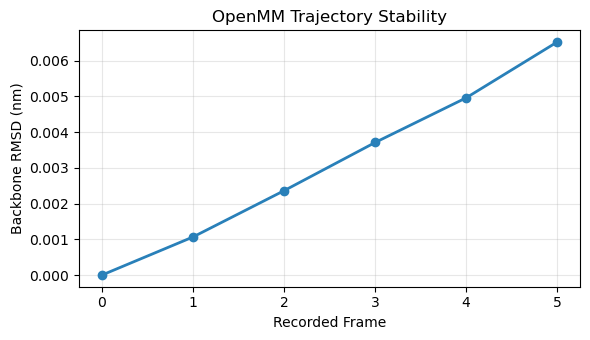

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.5))
frame_indices = range(len(rmsd_nm))
ax.plot(frame_indices, rmsd_nm, marker='o', color='#2980B9', linewidth=2)
ax.set_xlabel('Recorded Frame')
ax.set_ylabel('Backbone RMSD (nm)')
ax.set_title('OpenMM Trajectory Stability')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

:::{seealso}
:class: dropdown

- {func}`molsysmt.third_party.openmm.reporters.StructuresDictReporter`: In-memory trajectory reporter for OpenMM simulations.
- {func}`molsysmt.third_party.openmm.reporters.H5MSMReporter`: Direct H5MSM trajectory reporter for OpenMM.
- {func}`molsysmt.structure.get_rmsd`: Calculating RMSD on trajectory coordinates.
:::